# Exercise 4:
Claude was used to get the code for the plots.

Taylor Series Expansions about x₀ = 1, truncated at O((x-x₀)³)



<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

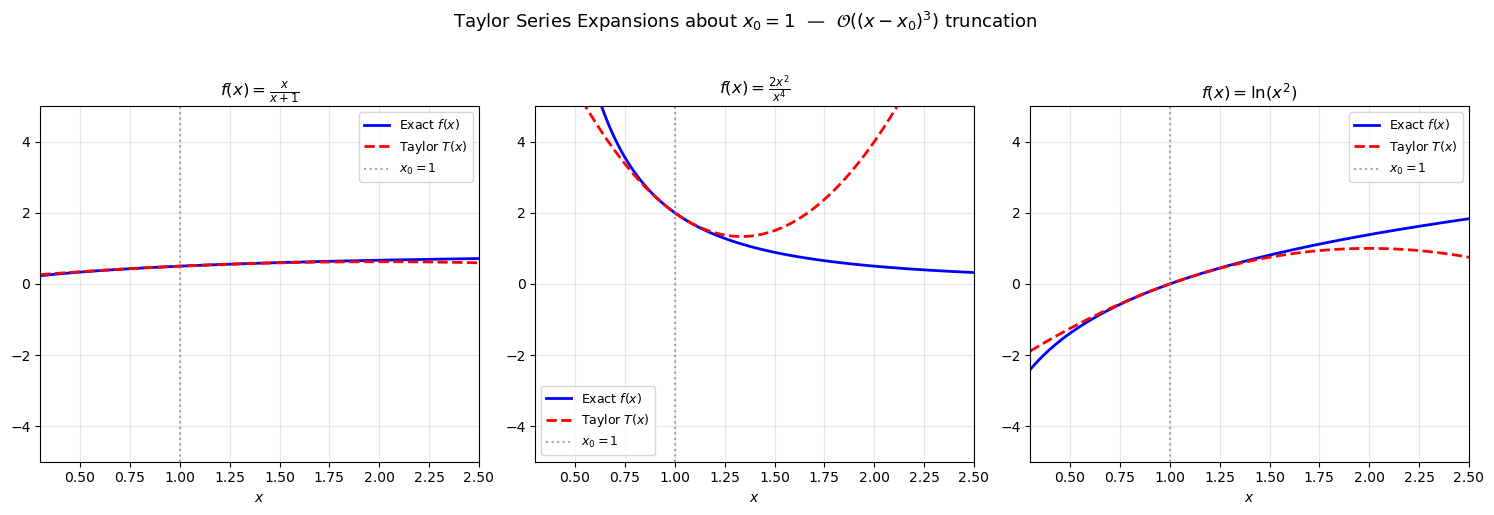

In [14]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Math

sp.init_printing(use_latex=True) #to make the functions aesthetic when printed 

x, x0 = sp.symbols('x x0')

functions = {
    r'f(x) = \frac{x}{x+1}':       x / (x + 1),
    r'f(x) = \frac{2x^2}{x^4}':    2*x**2 / x**4,
    r'f(x) = \ln(x^2)':            sp.ln(x**2),
}

def taylor_series(f, x, x0_sym, order=3):
    series = sp.Integer(0)
    for n in range(order):
        deriv = sp.diff(f, x, n)
        series += deriv.subs(x, x0_sym) / sp.factorial(n) * (x - x0_sym)**n
    return sp.simplify(series)

x0_val = 1

# --- Pretty-print each Taylor expansion ---
print("Taylor Series Expansions about x₀ = 1, truncated at O((x-x₀)³)\n")
print("=" * 60)

for label, f in functions.items():
    T = taylor_series(f, x, x0, order=3)
    T_num = sp.expand(T.subs(x0, x0_val))
    latex_expr = sp.latex(T_num)
    display(Math(r'%s \quad\Rightarrow\quad T(x) = %s + \mathcal{O}((x-x_0)^3)' % (label, latex_expr)))

print("\n" + "=" * 60 + "\n")

# --- Plotting ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (label, f) in zip(axes, functions.items()):
    T = taylor_series(f, x, x0, order=3)
    T_num = T.subs(x0, x0_val)

    f_func = sp.lambdify(x, f.subs(x0, x0_val), 'numpy')
    T_func = sp.lambdify(x, T_num, 'numpy')

    x_vals = np.linspace(0.3, 2.5, 400)
    y_exact  = np.clip(np.array(f_func(x_vals), dtype=float), -10, 10)
    y_taylor = np.clip(np.array(T_func(x_vals), dtype=float), -10, 10)

    ax.plot(x_vals, y_exact,  'b-',  linewidth=2, label='Exact $f(x)$')
    ax.plot(x_vals, y_taylor, 'r--', linewidth=2, label='Taylor $T(x)$')
    ax.axvline(x=x0_val, color='gray', linestyle=':', alpha=0.7, label=f'$x_0={x0_val}$')
    ax.set_ylim(-5, 5)
    ax.set_xlim(0.3, 2.5)
    ax.set_title(f'${label}$', fontsize=12)
    ax.set_xlabel('$x$')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle(r'Taylor Series Expansions about $x_0=1$  —  $\mathcal{O}((x-x_0)^3)$ truncation',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('taylor_series.png', dpi=150, bbox_inches='tight')
plt.show()

# Exercise 5:

STABILITY ANALYSIS: Amplification Factor  |g| = |C^(n+1) / C^n|


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

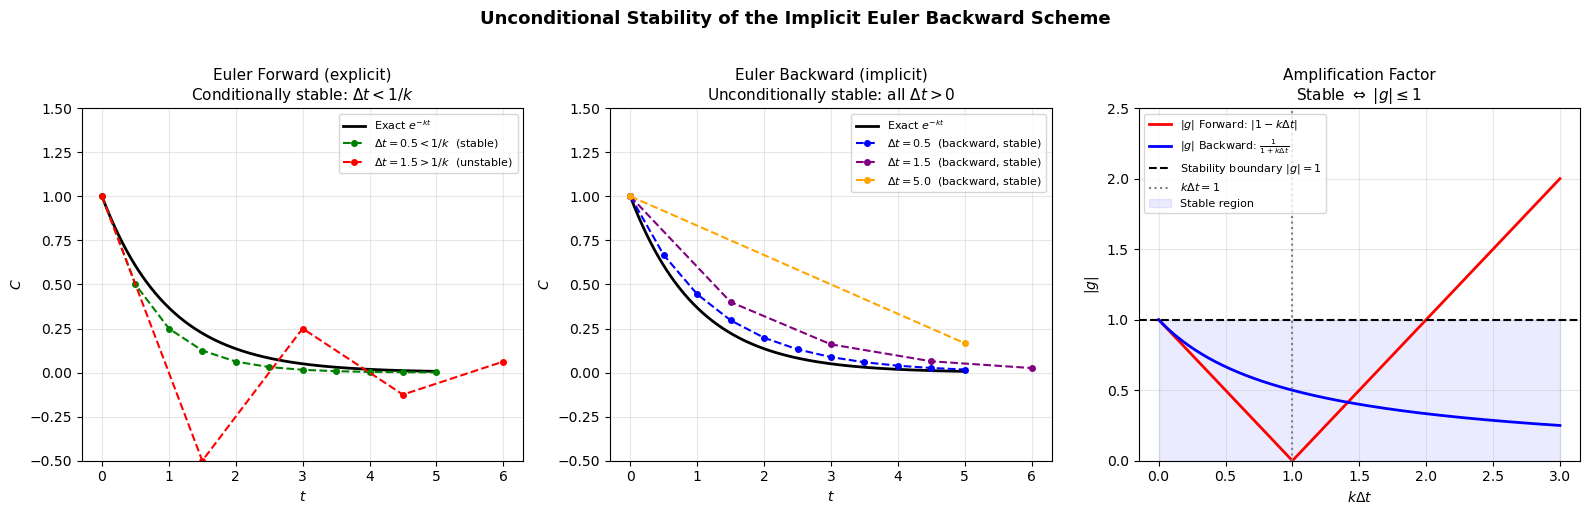

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Math
import sympy as sp

sp.init_printing(use_latex=True)

# ── Symbolic stability analysis ──────────────────────────────────────────────
k, dt = sp.symbols('k Delta_t', positive=True)

# Amplification factors
g_forward  = 1 - k*dt          # Explicit Euler forward
g_backward = 1 / (1 + k*dt)    # Implicit Euler backward

print("=" * 65)
print("STABILITY ANALYSIS: Amplification Factor  |g| = |C^(n+1) / C^n|")
print("=" * 65)

display(Math(r'\textbf{Euler Forward (explicit):}'))
display(Math(r'C^{n+1} = (1 - k\Delta t)\,C^n \quad \Rightarrow \quad g = '
             + sp.latex(g_forward)))
display(Math(r'\text{Stable only if } |1 - k\Delta t| \leq 1 '
             r'\quad \Rightarrow \quad \Delta t < \frac{1}{k} \quad '
             r'(\textit{conditionally stable})'))

print()
display(Math(r'\textbf{Euler Backward (implicit):}'))
display(Math(r'C^{n+1} = \dfrac{C^n}{1 + k\Delta t} \quad \Rightarrow \quad g = '
             + sp.latex(g_backward)))
display(Math(r'\text{Since } k > 0,\ \Delta t > 0: \quad 0 < \dfrac{1}{1+k\Delta t} < 1 '
             r'\quad \forall\, \Delta t > 0 \quad '
             r'(\textit{unconditionally stable})'))

print("\n" + "=" * 65 + "\n")

# ── Numerical demonstration ──────────────────────────────────────────────────
k_val  = 1.0
C0     = 1.0
t_end  = 5.0

t_exact = np.linspace(0, t_end, 500)
C_exact = C0 * np.exp(-k_val * t_exact)

dt_cases = {
    r'$\Delta t = 0.5 < 1/k$  (stable)':    (0.5, 'forward',  'green'),
    r'$\Delta t = 1.5 > 1/k$  (unstable)':  (1.5, 'forward',  'red'),
    r'$\Delta t = 0.5$  (backward, stable)': (0.5, 'backward', 'blue'),
    r'$\Delta t = 1.5$  (backward, stable)': (1.5, 'backward', 'purple'),
    r'$\Delta t = 5.0$  (backward, stable)': (5.0, 'backward', 'orange'),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Left: Euler Forward stability demo ──────────────────────────────────────
ax = axes[0]
ax.plot(t_exact, C_exact, 'k-', lw=2, label=r'Exact $e^{-kt}$')
for label, (dt_val, scheme, color) in dt_cases.items():
    if scheme != 'forward':
        continue
    t_num = np.arange(0, t_end + dt_val, dt_val)
    C_num = np.zeros(len(t_num))
    C_num[0] = C0
    for n in range(len(t_num) - 1):
        C_num[n+1] = (1 - k_val * dt_val) * C_num[n]
    ax.plot(t_num, C_num, 'o--', color=color, lw=1.5, markersize=4, label=label)
ax.set_title('Euler Forward (explicit)\n' + r'Conditionally stable: $\Delta t < 1/k$', fontsize=11)
ax.set_xlabel(r'$t$'); ax.set_ylabel(r'$C$')
ax.set_ylim(-0.5, 1.5); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# ── Middle: Euler Backward stability demo ────────────────────────────────────
ax = axes[1]
ax.plot(t_exact, C_exact, 'k-', lw=2, label=r'Exact $e^{-kt}$')
for label, (dt_val, scheme, color) in dt_cases.items():
    if scheme != 'backward':
        continue
    t_num = np.arange(0, t_end + dt_val, dt_val)
    C_num = np.zeros(len(t_num))
    C_num[0] = C0
    for n in range(len(t_num) - 1):
        C_num[n+1] = C_num[n] / (1 + k_val * dt_val)
    ax.plot(t_num, C_num, 'o--', color=color, lw=1.5, markersize=4, label=label)
ax.set_title('Euler Backward (implicit)\n' + r'Unconditionally stable: all $\Delta t > 0$', fontsize=11)
ax.set_xlabel(r'$t$'); ax.set_ylabel(r'$C$')
ax.set_ylim(-0.5, 1.5); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# ── Right: Amplification factor vs kΔt ──────────────────────────────────────
ax = axes[2]
kdt = np.linspace(0, 3, 400)
g_fwd = np.abs(1 - kdt)
g_bwd = 1 / (1 + kdt)

ax.plot(kdt, g_fwd, 'r-', lw=2, label=r'$|g|$ Forward: $|1 - k\Delta t|$')
ax.plot(kdt, g_bwd, 'b-', lw=2, label=r'$|g|$ Backward: $\frac{1}{1+k\Delta t}$')
ax.axhline(1, color='k', linestyle='--', lw=1.5, label=r'Stability boundary $|g|=1$')
ax.axvline(1, color='gray', linestyle=':', lw=1.5, label=r'$k\Delta t = 1$')
ax.fill_between(kdt, 0, 1, alpha=0.08, color='blue', label='Stable region')
ax.set_xlabel(r'$k\Delta t$'); ax.set_ylabel(r'$|g|$')
ax.set_title('Amplification Factor\n' + r'Stable $\Leftrightarrow$ $|g| \leq 1$', fontsize=11)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.set_ylim(0, 2.5)

plt.suptitle('Unconditional Stability of the Implicit Euler Backward Scheme',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('euler_stability.png', dpi=150, bbox_inches='tight')
plt.show()

# Exercise 6:

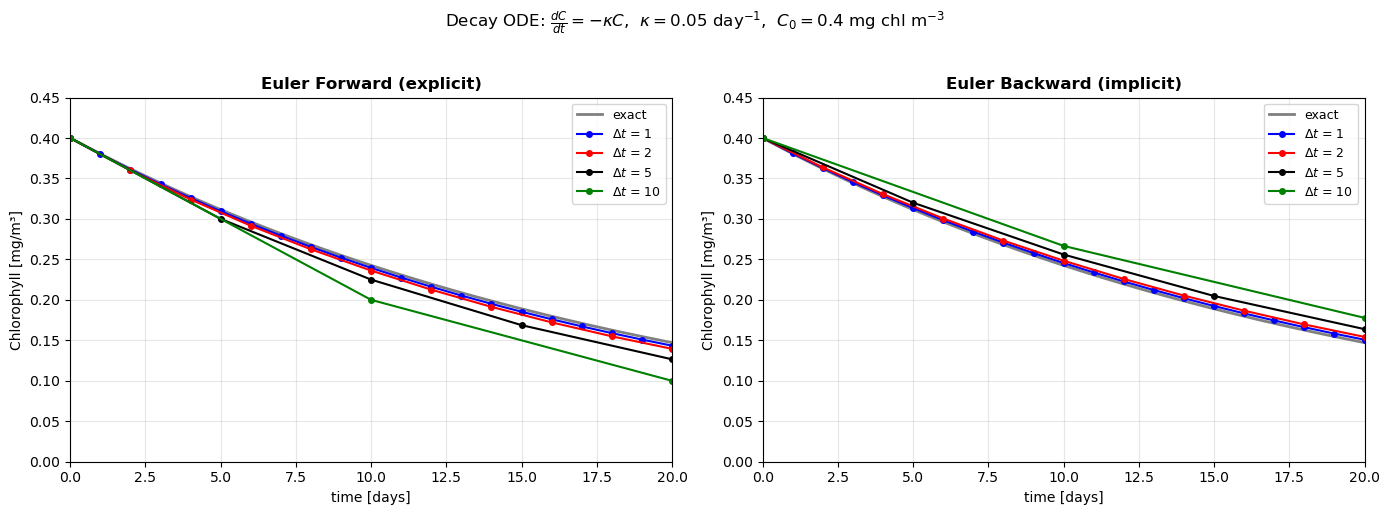

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Math

# ── Parameters (matching the MATLAB slide) ───────────────────────────────────
t0    = 0
tn    = 20
kappa = 0.05   # day^-1
C0    = 0.4    # mg chl m^-3

# Time steps to compare
dt_values = [1, 2, 5, 10]
colors     = ['blue', 'red', 'black', 'green']

# Exact solution
t_exact = np.linspace(t0, tn, 500)
C_exact = C0 * np.exp(-kappa * t_exact)

# ODE right-hand side: dC/dt = F(kappa, C)
F = lambda k, C: -k * C

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, method in zip(axes, ['forward', 'backward']):

    ax.plot(t_exact, C_exact, '-', color='grey', lw=2, label='exact')

    for dt, color in zip(dt_values, colors):
        Ntot = int(np.floor((tn - t0) / dt)) + 1
        t = np.zeros(Ntot)
        C = np.zeros(Ntot)
        t[0] = t0
        C[0] = C0

        for n in range(Ntot - 1):
            if method == 'forward':
                # Explicit: C^(n+1) = C^n + F(k, C^n) * dt
                C[n+1] = C[n] + F(kappa, C[n]) * dt
            else:
                # Implicit: C^(n+1) = C^n / (1 + kappa*dt)
                C[n+1] = C[n] / (1 + kappa * dt)
            t[n+1] = t[n] + dt

        ax.plot(t, C, 'o-', color=color, lw=1.5, markersize=4,
                label=r'$\Delta t$ = ' + str(dt))

    title = 'Euler Forward (explicit)' if method == 'forward' else 'Euler Backward (implicit)'
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('time [days]')
    ax.set_ylabel('Chlorophyll [mg/m³]')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(t0, tn)
    ax.set_ylim(0, C0 + 0.05)

plt.suptitle(r'Decay ODE: $\frac{dC}{dt} = -\kappa C$,  '
             r'$\kappa = 0.05\ \mathrm{day}^{-1}$,  $C_0 = 0.4\ \mathrm{mg\ chl\ m}^{-3}$',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('euler_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Print the schemes side by side ───────────────────────────────────────────
print("=" * 55)
display(Math(r'\textbf{Euler Forward:} \quad C^{n+1} = C^n + F(\kappa, C^n)\,\Delta t'))
display(Math(r'\textbf{Euler Backward:} \quad C^{n+1} = \frac{C^n}{1 + \kappa\,\Delta t}'))
print("=" * 55)

#### 